# __Preprocesamiento de los datos__

In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import holidays
import seaborn as sns

## Cargar datos

In [151]:
df1 = pd.read_excel('../data/Afluencia_2021.xlsx')
df2 = pd.read_excel('../data/Afluencia_2022.xlsx')
df3 = pd.read_excel('../data/Afluencia_2023.xlsx')
df4 = pd.read_excel('../data/Afluencia_2024.xlsx')
df5 = pd.read_excel('../data/Afluencia_2025.xlsx')

df_total = pd.concat([df1, df2, df3, df4, df5], ignore_index=True)
df_total

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20220,2025-09-30 00:00:00,LÍNEA K,2430.0,2828.0,2543.0,2160.0,1852.0,1345.0,1111.0,1204.0,...,753.0,1026.0,860.0,624.0,525.0,559.0,270.0,100.0,NaN,23385
20221,2025-09-30 00:00:00,LÍNEA M,381.0,1056.0,931.0,711.0,452.0,364.0,303.0,352.0,...,494.0,659.0,659.0,1178.0,891.0,526.0,402.0,306.0,74.0,10881
20222,2025-09-30 00:00:00,LÍNEA O,265.0,1592.0,1723.0,1820.0,1195.0,1190.0,850.0,1091.0,...,1145.0,1529.0,1810.0,1231.0,1119.0,904.0,825.0,310.0,14.0,21785
20223,2025-09-30 00:00:00,LÍNEA P,1315.0,3172.0,2793.0,2575.0,1621.0,1065.0,735.0,987.0,...,708.0,874.0,979.0,625.0,482.0,579.0,386.0,157.0,3.0,21684


In [152]:
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Fecha                                20225 non-null  object 
 1   Linea                                20225 non-null  object 
 2   04:00:00                             17109 non-null  float64
 3   05:00:00                             17186 non-null  float64
 4   06:00:00                             17190 non-null  float64
 5   07:00:00                             17204 non-null  float64
 6   08:00:00                             19301 non-null  float64
 7   09:00:00                             20177 non-null  float64
 8   10:00:00                             20169 non-null  float64
 9   11:00:00                             20160 non-null  float64
 10  12:00:00                             20166 non-null  float64
 11  13:00:00                    

## Limpiar datos

In [153]:
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,NaN,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,NaN,NaN,31911
1,2021-01-01 00:00:00,LÍNEA B,NaN,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,NaN,NaN,NaN,4050
2,2021-01-01 00:00:00,LÍNEA K,NaN,NaN,NaN,NaN,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,NaN,NaN,NaN,1714
3,2021-01-01 00:00:00,LÍNEA J,NaN,NaN,NaN,NaN,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,NaN,NaN,1256
4,2021-01-01 00:00:00,LÍNEA 1,NaN,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,NaN,NaN,6104


In [154]:
# convertir valores nulos en cero
df_total.fillna(0, inplace=True)
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01 00:00:00,LÍNEA A,0.0,3487.0,3405.0,2011.0,1148.0,974.0,888.0,1011.0,...,1833.0,2900.0,3269.0,3314.0,2273.0,1329.0,12.0,0.0,0.0,31911
1,2021-01-01 00:00:00,LÍNEA B,0.0,532.0,438.0,267.0,164.0,145.0,135.0,142.0,...,212.0,321.0,421.0,432.0,215.0,157.0,0.0,0.0,0.0,4050
2,2021-01-01 00:00:00,LÍNEA K,0.0,0.0,0.0,0.0,40.0,131.0,104.0,156.0,...,167.0,258.0,189.0,122.0,103.0,38.0,0.0,0.0,0.0,1714
3,2021-01-01 00:00:00,LÍNEA J,0.0,0.0,0.0,0.0,1.0,77.0,74.0,92.0,...,146.0,179.0,132.0,135.0,69.0,42.0,3.0,0.0,0.0,1256
4,2021-01-01 00:00:00,LÍNEA 1,0.0,614.0,590.0,355.0,240.0,217.0,198.0,231.0,...,394.0,579.0,624.0,574.0,399.0,231.0,17.0,0.0,0.0,6104


In [155]:
# convertir campos float a enteros
cols_float = df_total.select_dtypes(include='float').columns
df_total[cols_float] = df_total[cols_float].astype(int)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Fecha                                20225 non-null  object
 1   Linea                                20225 non-null  object
 2   04:00:00                             20225 non-null  int64 
 3   05:00:00                             20225 non-null  int64 
 4   06:00:00                             20225 non-null  int64 
 5   07:00:00                             20225 non-null  int64 
 6   08:00:00                             20225 non-null  int64 
 7   09:00:00                             20225 non-null  int64 
 8   10:00:00                             20225 non-null  int64 
 9   11:00:00                             20225 non-null  int64 
 10  12:00:00                             20225 non-null  int64 
 11  13:00:00                             2022

In [156]:
# convertir campo Fecha a datetime
df_total['Fecha'] = pd.to_datetime(df_total['Fecha'], dayfirst=True)
df_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20225 entries, 0 to 20224
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   Fecha                                20225 non-null  datetime64[ns]
 1   Linea                                20225 non-null  object        
 2   04:00:00                             20225 non-null  int64         
 3   05:00:00                             20225 non-null  int64         
 4   06:00:00                             20225 non-null  int64         
 5   07:00:00                             20225 non-null  int64         
 6   08:00:00                             20225 non-null  int64         
 7   09:00:00                             20225 non-null  int64         
 8   10:00:00                             20225 non-null  int64         
 9   11:00:00                             20225 non-null  int64         
 10  12:00:00  

In [157]:
df_total.head(5)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
0,2021-01-01,LÍNEA A,0,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,0,0,31911
1,2021-01-01,LÍNEA B,0,532,438,267,164,145,135,142,...,212,321,421,432,215,157,0,0,0,4050
2,2021-01-01,LÍNEA K,0,0,0,0,40,131,104,156,...,167,258,189,122,103,38,0,0,0,1714
3,2021-01-01,LÍNEA J,0,0,0,0,1,77,74,92,...,146,179,132,135,69,42,3,0,0,1256
4,2021-01-01,LÍNEA 1,0,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,0,0,6104


In [158]:
# quitar la palabra Linea del campo Linea
df_total['Linea'] = df_total['Linea'].str.replace('LÍNEA', '', regex=False)
df_total['Linea'] = df_total['Linea'].str.strip()
df_total.sample(10)

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total general (Número de pasajeros)
16569,2024-11-24,P,0,0,0,0,40,802,711,531,...,573,567,555,600,495,471,311,25,0,7808
4716,2022-02-20,J,0,0,0,0,27,857,759,680,...,645,672,653,629,592,475,224,13,0,8377
15764,2024-09-18,2,186,936,1002,1148,860,913,950,1052,...,1352,1941,2157,1708,1263,880,593,211,9,20465
11405,2023-09-10,H,0,0,0,0,1,104,106,84,...,61,92,85,78,55,51,37,2,0,989
11953,2023-10-26,P,1469,3421,3238,2336,1319,908,767,1214,...,698,908,1207,538,393,716,448,144,0,22383
7328,2022-09-30,B,3096,7462,8932,8799,5539,4511,3948,4291,...,6012,7486,9876,7782,4775,3651,3142,4059,33,108119
19182,2025-07-04,P,1171,3050,2970,2343,1416,941,853,1024,...,791,927,931,640,572,839,441,156,2,22136
3652,2021-11-22,M,306,754,762,493,325,288,220,249,...,384,526,852,944,782,426,214,213,65,8672
4679,2022-02-17,2,168,769,927,963,836,882,942,1063,...,1193,1809,2085,1759,1136,832,530,213,5,19288
20054,2025-09-16,K,2235,2699,2665,2414,1841,1324,1150,1115,...,775,1071,900,723,545,512,233,87,1,23356


In [159]:
# cambiar nombre de la variable 'Total general (Número de pasajeros)'
df_total = df_total.rename(columns={'Total general (Número de pasajeros)':'Total pasajeros'})
df_total.sample()

,Fecha,Linea,04:00:00,05:00:00,06:00:00,07:00:00,08:00:00,09:00:00,10:00:00,11:00:00,...,15:00:00,16:00:00,17:00:00,18:00:00,19:00:00,20:00:00,21:00:00,22:00:00,23:00:00,Total pasajeros
5797,2022-05-22,M,0,0,0,0,6,288,240,259,...,417,382,401,407,379,321,300,153,0,4628


In [160]:
# cambiar nombre de las horas
df_total.columns = (
    ['Fecha', 'Linea'] +
    [str(col)[:2] for col in df_total.columns[2:22]] +
    ['Total Pasajeros']
)

df_total.head()

,Fecha,Linea,04,05,06,07,08,09,10,11,...,15,16,17,18,19,20,21,22,23,Total Pasajeros
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,1833,2900,3269,3314,2273,1329,12,0,0,31911
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,212,321,421,432,215,157,0,0,0,4050
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,167,258,189,122,103,38,0,0,0,1714
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,146,179,132,135,69,42,3,0,0,1256
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,394,579,624,574,399,231,17,0,0,6104


## Features ingening

In [161]:
# crear un campo que almacene el respectivo ano de cada fecha
df_total['Year'] = df_total['Fecha'].dt.year
df_total.head()

,Fecha,Linea,04,05,06,07,08,09,10,11,...,16,17,18,19,20,21,22,23,Total Pasajeros,Year
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,2900,3269,3314,2273,1329,12,0,0,31911,2021
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,321,421,432,215,157,0,0,0,4050,2021
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,258,189,122,103,38,0,0,0,1714,2021
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,179,132,135,69,42,3,0,0,1256,2021
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,579,624,574,399,231,17,0,0,6104,2021


In [162]:
# crear un campo que almacene los dias de la semana
df_total['Day'] = df_total['Fecha'].dt.day_name()
df_total.head()

,Fecha,Linea,04,05,06,07,08,09,10,11,...,17,18,19,20,21,22,23,Total Pasajeros,Year,Day
0,2021-01-01,A,0,3487,3405,2011,1148,974,888,1011,...,3269,3314,2273,1329,12,0,0,31911,2021,Friday
1,2021-01-01,B,0,532,438,267,164,145,135,142,...,421,432,215,157,0,0,0,4050,2021,Friday
2,2021-01-01,K,0,0,0,0,40,131,104,156,...,189,122,103,38,0,0,0,1714,2021,Friday
3,2021-01-01,J,0,0,0,0,1,77,74,92,...,132,135,69,42,3,0,0,1256,2021,Friday
4,2021-01-01,1,0,614,590,355,240,217,198,231,...,624,574,399,231,17,0,0,6104,2021,Friday


In [163]:
# crear un campo que almacene los meses de la semana
df_total['Month'] = df_total['Fecha'].dt.month_name()
df_total.sample(5)

,Fecha,Linea,04,05,06,07,08,09,10,11,...,18,19,20,21,22,23,Total Pasajeros,Year,Day,Month
12297,2023-11-26,M,0,0,0,0,12,346,283,265,...,452,399,410,350,142,0,5043,2023,Sunday,November
11712,2023-10-06,B,3117,9319,9602,7886,5365,4796,4171,4360,...,6956,4173,3566,2712,1696,0,107734,2023,Friday,October
1669,2021-06-05,M,160,430,422,314,229,186,206,240,...,120,186,311,226,164,31,4076,2021,Saturday,June
8133,2022-12-08,J,0,0,0,0,45,1007,716,722,...,889,568,449,255,65,0,9073,2022,Thursday,December
11078,2023-08-13,B,648,1750,2093,1996,1960,2359,2431,2391,...,3012,2350,2021,1541,1776,0,44927,2023,Sunday,August


## Analisis

### Promedio de pasajeros por hora para el periodo que va del 2021 al 2025 

In [164]:
# listar las horas, lineas y años
horas = [c for c in df_total.columns if c not in ("Fecha", "Linea", "Year", "Total Pasajeros", 'Month', 'Day')]
lineas = sorted(df_total["Linea"].unique())
year = sorted(df_total["Year"].unique())

# transformar formato de los datos en largo
df_long = df_total.melt(
    id_vars=["Fecha", "Linea", "Year"],
    value_vars=horas,
    var_name="Hora",
    value_name="Pasajeros"
)

# obtener el promedio de pasajeros para cada año, por linea y por hora.
promedio = (
    df_long
    .groupby(["Year", "Linea", "Hora"])["Pasajeros"]
    .mean()
    .reset_index()
)

# ordenar los datos cronologicamente
promedio["Hora_idx"] = pd.Categorical(promedio["Hora"], categories=horas, ordered=True)
promedio = promedio.sort_values(["Year", "Linea", "Hora_idx"])
promedio

,Year,Linea,Hora,Pasajeros,Hora_idx
0,2021,1,04,1919.353425,04
1,2021,1,05,5154.684932,05
2,2021,1,06,6349.567123,06
3,2021,1,07,5771.205479,07
4,2021,1,08,3931.764384,08
...,...,...,...,...,...
1195,2025,T-A,19,2734.670330,19
1196,2025,T-A,20,2051.644689,20
1197,2025,T-A,21,1638.890110,21
1198,2025,T-A,22,1010.791209,22


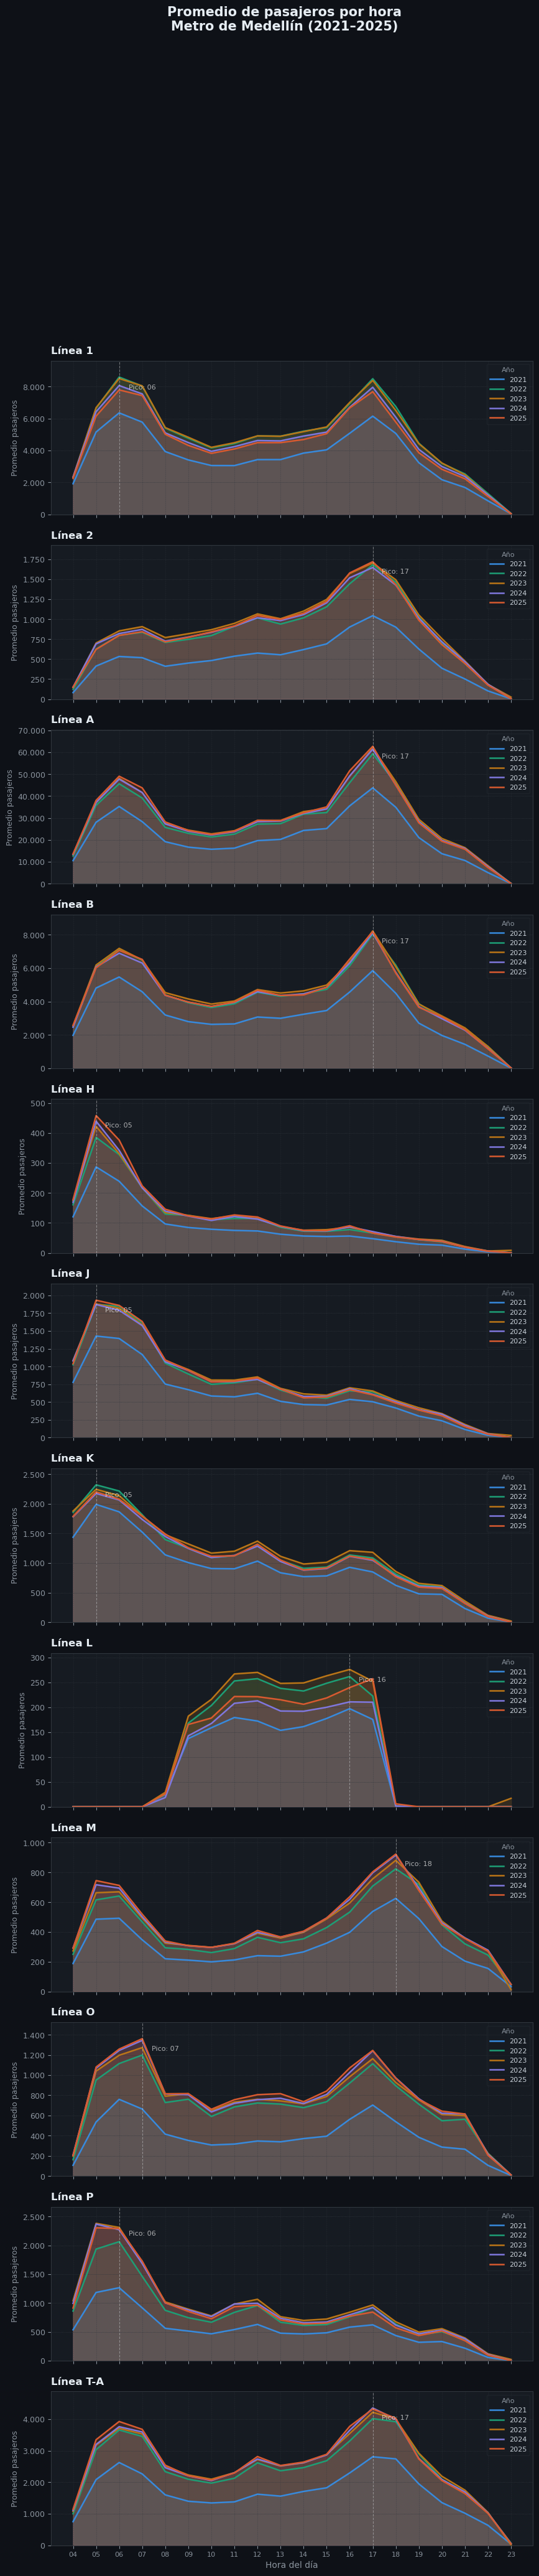

In [165]:
# un color para cada año
PALETA = {
    2021: "#378ADD",
    2022: "#1D9E75",
    2023: "#BA7517",
    2024: "#7F77DD",
    2025: "#D85A30",
}
 
horas = [f"{h:02d}" for h in range(4, 24)]
HORA_LABELS = [h[:5] for h in horas]

# obtener cantidad de lineas
n_lineas = len(lineas)

# crear una subgrafica para cada linea del metro
fig, axes = plt.subplots(
    n_lineas, 1,
    figsize=(10, 3.8 * n_lineas),
    sharex=True,
    facecolor="#0e1117"
)

if n_lineas == 1:
    axes = [axes]

# definir color de fondo de la figura 
fig.patch.set_facecolor("#0e1117")
 
for ax, linea in zip(axes, lineas):
    ax.set_facecolor("#161b22")
    ax.spines[:].set_color("#30363d")
    ax.tick_params(colors="#8b949e", labelsize=9)
    ax.yaxis.label.set_color("#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
 
    datos_linea = promedio[promedio["Linea"] == linea].copy()
    y_max_global = 0
 
    for año in year:
        datos_año = datos_linea[datos_linea["Year"] == año].copy()
        if datos_año.empty:
            continue
        y = datos_año["Pasajeros"].values
        x = np.arange(len(horas))
        color = PALETA[año]
        ax.fill_between(x, y, alpha=0.18, color=color)
        ax.plot(x, y, color=color, linewidth=1.8, label=str(año))
        y_max_global = max(y_max_global, y.max())
 
    # Marcar hora pico del promedio total
    promedio_total = datos_linea.groupby("Hora_idx", observed=True)["Pasajeros"].mean().values
    idx_pico = np.argmax(promedio_total)
    ax.axvline(idx_pico, color="#f0f0f0", linewidth=0.8, linestyle="--", alpha=0.4)
    ax.annotate(
        f"Pico: {HORA_LABELS[idx_pico]}",
        xy=(idx_pico, y_max_global * 0.95),
        xytext=(idx_pico + 0.4, y_max_global * 0.95),
        fontsize=8, color="#f0f0f0", alpha=0.7,
        va="top"
    )
 
    ax.set_ylabel("Promedio pasajeros", fontsize=9, color="#8b949e")
    ax.set_title(f"Línea {linea}", fontsize=12, fontweight="bold",
                 color="#e6edf3", loc="left", pad=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f"{int(v):,}".replace(",", ".")
    ))
    ax.set_ylim(0, y_max_global * 1.12)
    ax.grid(axis="y", color="#30363d", linewidth=0.6, linestyle=":")
    ax.grid(axis="x", color="#30363d", linewidth=0.4, linestyle=":")
 
    # Leyenda dentro del panel
    leg = ax.legend(
        title="Año", title_fontsize=8,
        fontsize=8, loc="upper right",
        framealpha=0.3, frameon=True,
        labelcolor="#c9d1d9",
        facecolor="#161b22", edgecolor="#30363d"
    )
    leg.get_title().set_color("#8b949e")
 
# Eje X compartido
axes[-1].set_xticks(np.arange(len(horas)))
axes[-1].set_xticklabels(HORA_LABELS, rotation=0, ha="center", fontsize=8, color="#8b949e")
axes[-1].set_xlabel("Hora del día", fontsize=10, color="#8b949e")
 
fig.suptitle(
    "Promedio de pasajeros por hora\nMetro de Medellín (2021–2025)",
    fontsize=15, fontweight="bold", color="#e6edf3",
    y=1.005
)

plt.show()

### Heatmap de hora x linea

In [166]:
# clasificar los dias por habiles y fin de semana
df_total['tipo_dia'] = df_total['Fecha'].dt.day_of_week.map(
    lambda d: 'habil' if d < 5 else 'fin de semana'
)

# clasificar los dias festivos como fin de semana
festivos = holidays.Colombia(years=range(2021, 2026))
df_total.loc[df_total['Fecha'].isin(festivos), 'tipo_dia'] = 'fin de semana'

# convertir de formato ancho a largo
horas = [c for c in df_total.columns if c not in ('Fecha', 'Linea', 'tipo_dia', 'Total Pasajeros', 'Year', 'Day', 'Month')]

df_long = df_total.melt(
    id_vars=['Linea', 'tipo_dia'],
    value_vars=horas,
    var_name='Hora',
    value_name='Pasajeros'
)

df_long.sample(5)

,Linea,tipo_dia,Hora,Pasajeros
47300,2,fin de semana,06,237
138854,T-A,habil,10,2362
380986,O,fin de semana,22,24
219851,2,habil,14,1268
326680,K,habil,20,532


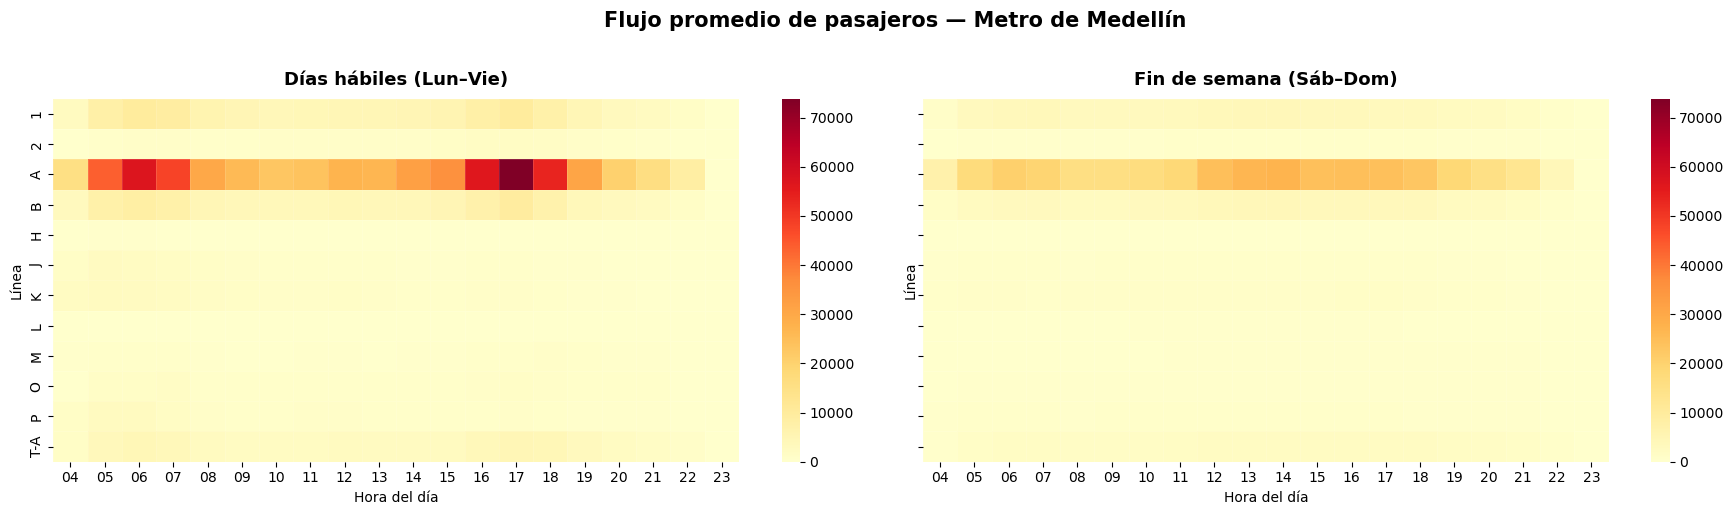

In [167]:
# funcion de la matriz linea x hora
def build_matrix(tipo):
    subset = df_long[df_long['tipo_dia'] == tipo]
    matriz = subset.pivot_table(
        index='Linea',
        columns='Hora',
        values='Pasajeros',
        aggfunc='mean'
    )

    # ordenar columnas cronologicamente
    matriz = matriz[sorted(matriz.columns)]
    return matriz

# matriz de los dias habiles y fines de semana
mat_habil = build_matrix('habil')
mat_finde = build_matrix('fin de semana')

# definir la misma escala de color a cada heatmap
vmax = max(mat_habil.values.max(), mat_finde.values.max())
paleta = 'YlOrRd'

# crear grafica de heatmap
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), sharey=True)
hora_labels = [h[:5] for h in mat_habil.columns]

for ax, mat, titulo in [(ax1, mat_habil, "Días hábiles (Lun–Vie)"), (ax2, mat_finde, "Fin de semana (Sáb–Dom)")]:

    sns.heatmap(
        mat, ax=ax,
        cmap=paleta, vmin=0, vmax=vmax,
        xticklabels=hora_labels,
        linewidths=0.4, linecolor="#ffffff20",
        annot=False,           # True si quieres números en celdas
        fmt=".0f", cbar=True
    )

    ax.set_title(titulo, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Línea")
    ax.tick_params(axis="x", rotation=0)

    fig.suptitle("Flujo promedio de pasajeros — Metro de Medellín",
             fontsize=15, fontweight="bold", y=1.02)

plt.tight_layout()
plt.savefig("heatmap_metro.png", dpi=150, bbox_inches="tight")
plt.show()